In [4]:
import pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from scipy.stats import chi2_contingency
from utils import get_data
import numpy as np


##################
# CARGA DE DATOS #
##################

df = get_data()

print(df.head())


         ID Case Number                Date                     Block  IUCR  \
0  10365064    HZ100370 2015-12-31 23:59:00       075XX S EMERALD AVE  1320   
1  10460641    HZ199559 2015-12-31 23:59:00        015XX N KEDZIE AVE  0890   
2  10364662    HZ100006 2015-12-31 23:55:00  079XX S STONY ISLAND AVE  0430   
3  10364740    HZ100010 2015-12-31 23:50:00         024XX W FARGO AVE  0820   
4  10364683    HZ100002 2015-12-31 23:50:00          037XX N CLARK ST  0460   

      Primary Type                    Description     Location Description  \
0  CRIMINAL DAMAGE                     TO VEHICLE                   STREET   
1            THEFT                  FROM BUILDING  RESIDENCE PORCH/HALLWAY   
2          BATTERY  AGGRAVATED: OTHER DANG WEAPON                   STREET   
3            THEFT                 $500 AND UNDER                APARTMENT   
4          BATTERY                         SIMPLE                 SIDEWALK   

   Arrest  Domestic  ...  Ward  Community Area  FBI Code

In [3]:
###############################
# CARACTERÍSTICAS PRINCIPALES #
###############################

fils_n, cols_n = df.shape
print(f"Observaciones: {fils_n:,}")
print(f"Variables: {cols_n}\n")

print(f"Data de cada variable")
resumen = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "n_unicos": df.nunique(),
    "n_nulos": df.isna().sum(),
    "%_nulos": (df.isna().mean() * 100).round(2),
    "ejemplo": df.iloc[0],
})
print(resumen)
# Notar la cantidad de nulos en las variables de data geográfica
# son todos casos donde la locación no está disponible
# Los datos de localización en sí no son exactos para proteger la identidad de las víctimas

print(f"\nClasificación de cada variable")
tipos = {
    "Identificadores": ["ID", "Case Number"],
    "Categóricas nominales": ["IUCR", "Primary Type", "Description", "FBI Code", "Location Description", "Block","Location","Beat","District","Ward", "Community Area"],
    "Cuantitativas continuas": ["X Coordinate", "Y Coordinate", "Latitude", "Longitude"],
    "Temporales": ["Date", "Year","Updated On"],
    "Categóricas binarias": ["Arrest", "Domestic"]
}
for k, v in tipos.items():
    print(f"- {k}: {v}")

# Algunas variables como Beat, District, Ward y Community Area son representadas con números
# pero no tienen valor numérico, representan barrios o comunas
# Year es una variable redundante dado que el dataset es específicamente del año 2015


Observaciones: 264,910
Variables: 22

Data de cada variable
                               dtype  n_unicos  n_nulos  %_nulos  \
ID                             int64    264910        0     0.00   
Case Number                      str    264883        0     0.00   
Date                  datetime64[us]    112355        0     0.00   
Block                            str     27523        0     0.00   
IUCR                             str       329        0     0.00   
Primary Type                     str        32        0     0.00   
Description                      str       342        0     0.00   
Location Description             str       140      620     0.23   
Arrest                          bool         2        0     0.00   
Domestic                        bool         2        0     0.00   
Beat                           int64       274        0     0.00   
District                       int64        23        0     0.00   
Ward                         float64        50        2 


Top 15 tipos de delito (% del total):
Primary Type
THEFT                         21.65
BATTERY                       18.47
CRIMINAL DAMAGE               10.83
NARCOTICS                      9.04
OTHER OFFENSE                  6.63
ASSAULT                        6.44
DECEPTIVE PRACTICE             6.23
BURGLARY                       4.98
MOTOR VEHICLE THEFT            3.80
ROBBERY                        3.64
CRIMINAL TRESPASS              2.42
WEAPONS VIOLATION              1.27
OFFENSE INVOLVING CHILDREN     0.95
PUBLIC PEACE VIOLATION         0.91
PROSTITUTION                   0.50
Name: count, dtype: float64


Text(0.5, 0, 'Cantidad')

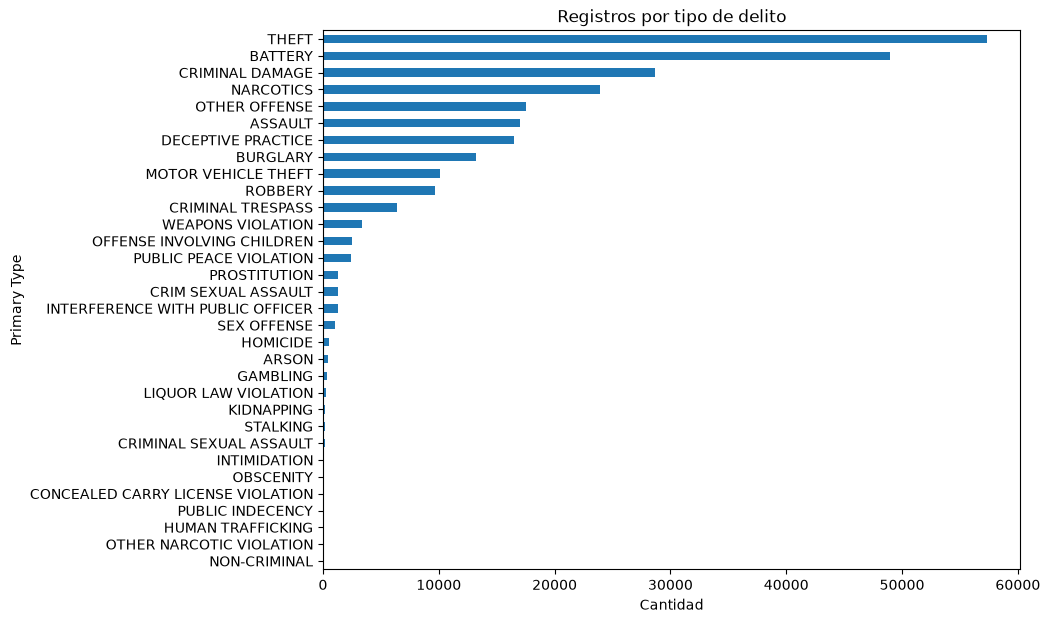

In [4]:
#############################
# PATRONES Y DISTRIBUCIONES #
#############################

# Destructuración de la fecha para entrar más en detalle
df["mes"] = df["Date"].dt.month
# 0 -> Lunes
df["dia_semana"] = df["Date"].dt.dayofweek
df["hora"] = df["Date"].dt.hour
df["dia_mes"] = df["Date"].dt.day
df["minuto"] = df["Date"].dt.minute

# Tipo de delito
tipo = df["Primary Type"].value_counts()
print("\nTop 15 tipos de delito (% del total):")
print((tipo.head(15) / fils_n * 100).round(2))
# Nótese que el top 3 incluye el 50.9% de los crímenes y el top 10 incluye del 91.7%
# hay cierta asimetría en el tipo de dato cometido

plt.figure(figsize=(9, 7))
tipo.sort_values().plot(kind="barh")
plt.title("Registros por tipo de delito")
plt.xlabel("Cantidad")


Tasa de arresto global (%): 26.5%
Porcentaje de casos domésticos: 18.5%

Tasa de arresto por tipo:
                                     mean   size
Primary Type                                    
GAMBLING                           100.00    310
NON-CRIMINAL                       100.00      1
PUBLIC INDECENCY                   100.00     14
NARCOTICS                           99.97  23939
PROSTITUTION                        99.85   1322
LIQUOR LAW VIOLATION                99.66    292
CONCEALED CARRY LICENSE VIOLATION   97.06     34
INTERFERENCE WITH PUBLIC OFFICER    95.80   1308
WEAPONS VIOLATION                   79.76   3364
PUBLIC PEACE VIOLATION              77.66   2422
OBSCENITY                           71.43     49
CRIMINAL TRESPASS                   68.68   6401
HOMICIDE                            44.42    502
OTHER NARCOTIC VIOLATION            40.00      5
HUMAN TRAFFICKING                   30.77     13
OTHER OFFENSE                       27.31  17566
ASSAULT           

Text(0.5, 0, '% con arresto')

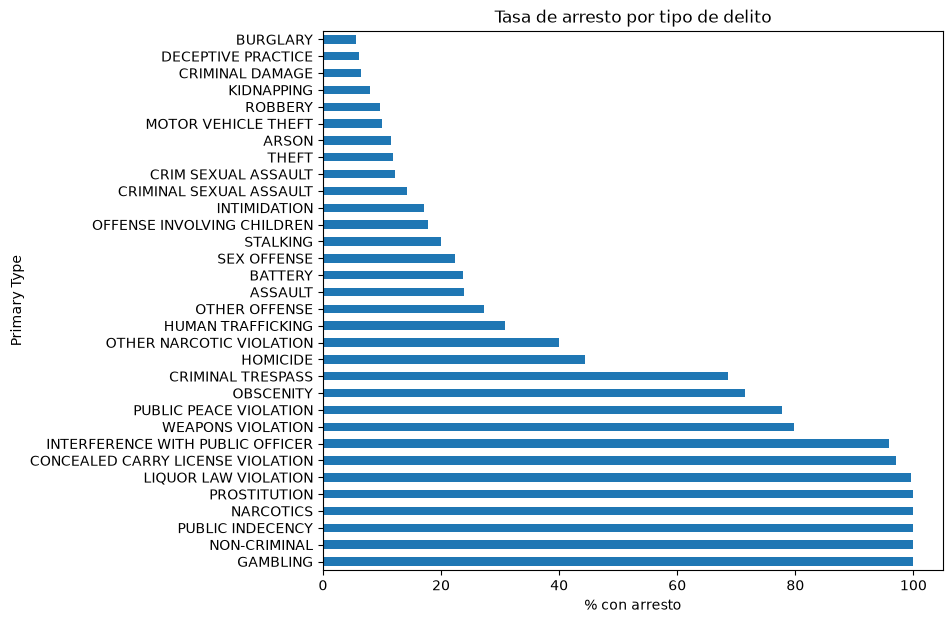

In [5]:
# Tasa de arresto y violencia doméstica (variables binarias)
# Dado que es binario 0/1 podemos sacar el porcentaje de arrestos/casos domésticos con un mean
print(f"\nTasa de arresto global (%): {df['Arrest'].mean():.1%}")
print(f"Porcentaje de casos domésticos: {df['Domestic'].mean():.1%}")
tasa_arresto = df.groupby("Primary Type")["Arrest"].agg(["mean", "size"])
print("\nTasa de arresto por tipo:")
tasa_arresto.sort_values("mean", ascending=False, inplace=True)
tasa_arresto["mean"] = tasa_arresto["mean"]*100
print(tasa_arresto.round(2))
# Ciertas categorías de delito como apuestas, narcóticos, prostitución, violación de ley de licor y armas
# casi siempre tienen arrestos porque el delito es "reactivo" - se ficha cuándo ya hubo un arresto

plt.figure(figsize=(8, 7))
tasa_arresto["mean"].plot(kind="barh")
plt.title("Tasa de arresto por tipo de delito")
plt.xlabel("% con arresto")


Crímenes registrados por mes:
mes
1     21022
2     16410
3     21694
4     21747
5     23733
6     23199
7     24250
8     24833
9     23141
10    23117
11    20606
12    21158
Name: count, dtype: int64


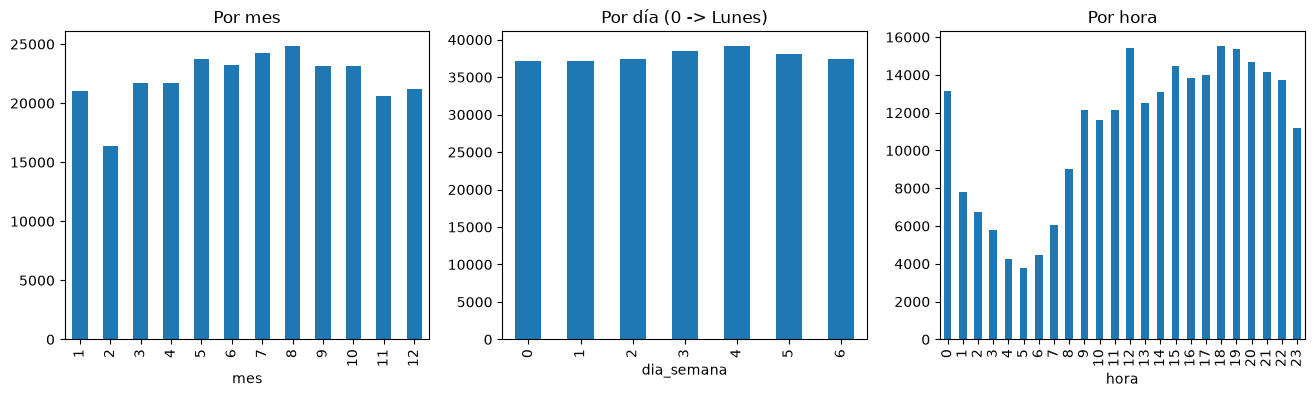

In [6]:
fig, ax = plt.subplots(1, 3, figsize=(16, 4))
df["mes"].value_counts().sort_index().plot(kind="bar", ax=ax[0], title="Por mes")
df["dia_semana"].value_counts().sort_index().plot(kind="bar", ax=ax[1],
                                                  title="Por día (0 -> Lunes)")
df["hora"].value_counts().sort_index().plot(kind="bar", ax=ax[2], title="Por hora")

print("\nCrímenes registrados por mes:")
print(df["mes"].value_counts().sort_index())
# Notar estacionalidad: mínimo es en febrero (mes más corto del año, es pleno invierno)
# y el máximo es en agosto (mes largo, es pleno verano)
# Hay poca variabilidad en cuánto al día de la semana en que ocurre el crimen
#Por hora, parece haber un pico al mediodía y continuar alto hasta la medianoche
# mientras que baja a la madrugada
# Sin embargo, dado que la hora puede ser la hora en la que el crimen queda registrado
# y no necesariamente el horario en que ocurrió el crimen algunos horarios pueden estar inflados


Top 15 descripciones de lugar:
Location Description
STREET                            60755
RESIDENCE                         41912
APARTMENT                         35113
SIDEWALK                          27875
OTHER                             10596
PARKING LOT/GARAGE(NON.RESID.)     7428
ALLEY                              5616
RESIDENTIAL YARD (FRONT/BACK)      5510
SMALL RETAIL STORE                 5488
RESTAURANT                         5008
RESIDENCE PORCH/HALLWAY            4770
VEHICLE NON-COMMERCIAL             4694
RESIDENCE-GARAGE                   4475
SCHOOL, PUBLIC, BUILDING           4164
DEPARTMENT STORE                   4127
Name: count, dtype: int64

Registros por distrito policial:
District
1     12005
2     10783
3     13090
4     15896
5     11371
6     16086
7     15781
8     17356
9     12769
10    11805
11    19537
12    12359
14     8954
15    11761
16     9439
17     7745
18    11385
19    11579
20     4279
22     8779
24     7051
25    15091
31        9
Na

Text(0, 0.5, 'Latitud')

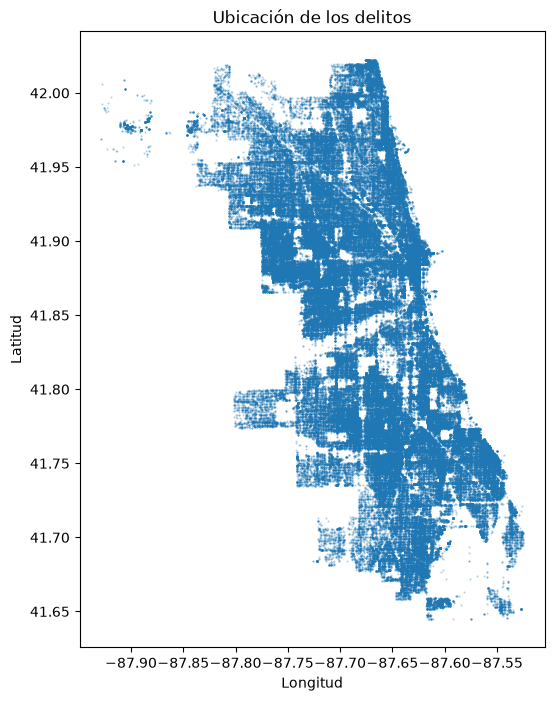

In [7]:
# Locación
print("\nTop 15 descripciones de lugar:")
print(df["Location Description"].value_counts().head(15))

print("\nRegistros por distrito policial:")
print(df["District"].value_counts().sort_index())
por_area = df.groupby("Community Area").size()
#Chicago se encuentra dividido geográficamente por "community areas", similares a barrios
print("\nRegistros por Community Area (77 áreas):")
print(por_area.describe().round(1))
# Notese la diferencia entre las áreas con máxima cantidad de delitos (17,436) vs. el
# mínimo (258). Hay mucha varianza según la zona

muestra = df.dropna(subset=["Latitude"])
plt.figure(figsize=(6, 8))
plt.scatter(muestra["Longitude"], muestra["Latitude"], s=0.3, alpha=0.3)
plt.title("Ubicación de los delitos")
plt.xlabel("Longitud")
plt.ylabel("Latitud")


Media                 725.78
Mediana               732.00
Moda                  745.00
Media cortada 5%      726.32
Desvío estándar        92.76
Varianza             8603.63
IQR                   105.00
IQR / rango             0.12
MAD                    52.00
Asimetría               0.37
Curtosis (exceso)       4.42
dtype: float64


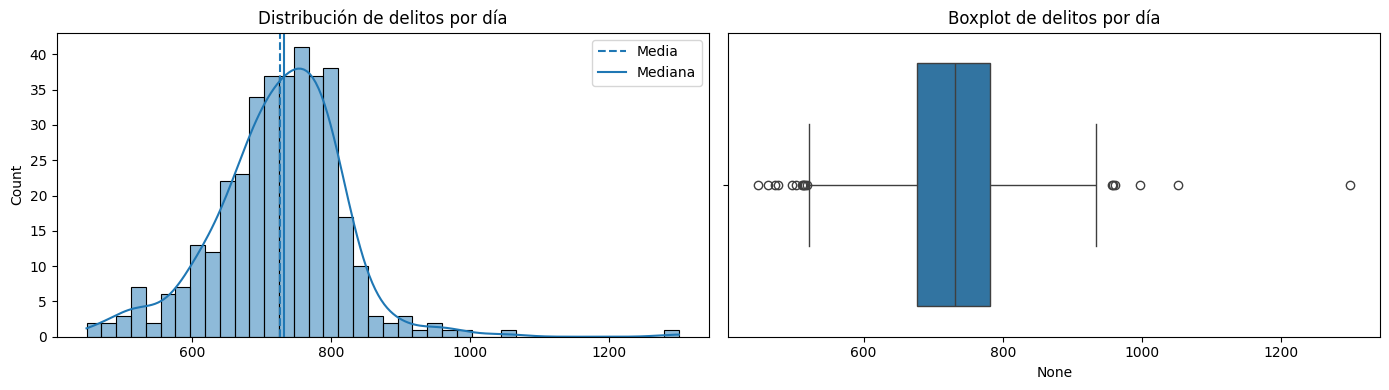

In [ ]:
# El dataset no tiene variables numéricas reales (las coordenadas y ubicaciones son cuantitativas continuas
# y categóricas nominales). Podemos crear una columna de delitos por día para realizar el análisis

from scipy.stats import trim_mean, median_abs_deviation

por_dia = df.groupby(df["Date"].dt.date).size()

q1, q3 = por_dia.quantile([0.25, 0.75])
iqr = q3 - q1
rango = por_dia.max() - por_dia.min()

estadisticos = pd.Series({
    "Media": por_dia.mean(),
    "Mediana": por_dia.median(),
    "Moda": por_dia.mode().iloc[0],
    "Media cortada 5%": trim_mean(por_dia, 0.05),
    "Desvío estándar": por_dia.std(),
    "Varianza": por_dia.var(),
    "IQR": iqr,
    "IQR / rango": iqr / rango,
    "MAD": median_abs_deviation(por_dia),
    "Asimetría": por_dia.skew(),
    "Curtosis (exceso)": por_dia.kurt(),
})
print(estadisticos.round(2))

fig, ax = plt.subplots(1, 2, figsize=(14, 4))
sns.histplot(por_dia, bins=40, kde=True, ax=ax[0])
ax[0].axvline(por_dia.mean(),  ls="--", label="Media")
ax[0].axvline(por_dia.median(),  ls="-", label="Mediana")
ax[0].set_title("Distribución de delitos por día")
ax[0].legend()
sns.boxplot(x=por_dia, ax=ax[1],)
ax[1].set_title("Boxplot de delitos por día")
plt.tight_layout()
plt.show()

In [ ]:
from scipy.stats import entropy

# Variables categóricas
categorias = ["Primary Type", "Description", "IUCR", "FBI Code", "Location Description",
        "District", "Beat", "Ward", "Community Area", "Block", "Domestic", "Arrest"]

# Calculamos la entropía de Shanon normaliada - 1 si está bien distribuida, cerca de 0 si hay una categoría dominante
def shannon(serie):
    frec = serie.value_counts()
    h = entropy(frec, base=2)
    h_max = np.log2(len(frec)) if len(frec) > 1 else 0
    return h, h_max, (h / h_max if h_max > 0 else 0)


filas = []
for c in categorias:
    s = df[c].dropna()
    frec = s.value_counts(normalize=True)
    h, h_max, h_norm = shannon(s)
    filas.append({
        "variable": c,
        "cardinalidad": s.nunique(),
        "moda": frec.index[0],
        "prop_moda": round(frec.iloc[0], 3),
        "rango_frec": s.value_counts().iloc[0] - s.value_counts().iloc[-1],
        "entropía": h.round(2),
        "entropía_max": h_max.round(2),
        "entropía_norm": h_norm.round( 2),
    })
tabla_cat = pd.DataFrame(filas).set_index("variable")
tabla_cat

,cardinalidad,moda,prop_moda,rango_frec,entropía,entropía_max,entropía_norm
variable,,,,,,,
Primary Type,32,THEFT,0.217,57354,3.49,5.00,0.70
Description,342,SIMPLE,0.103,27417,5.47,8.42,0.65
IUCR,329,0820,0.093,24678,5.63,8.36,0.67
FBI Code,26,06,0.217,57349,3.57,4.70,0.76
Location Description,140,STREET,0.230,60754,4.08,7.13,0.57
District,23,11,0.074,19528,4.40,4.52,0.97
Beat,274,421,0.009,2250,7.99,8.10,0.99
Ward,50,28.0,0.050,10833,5.45,5.64,0.97
Community Area,77,25.0,0.066,17178,5.82,6.27,0.93


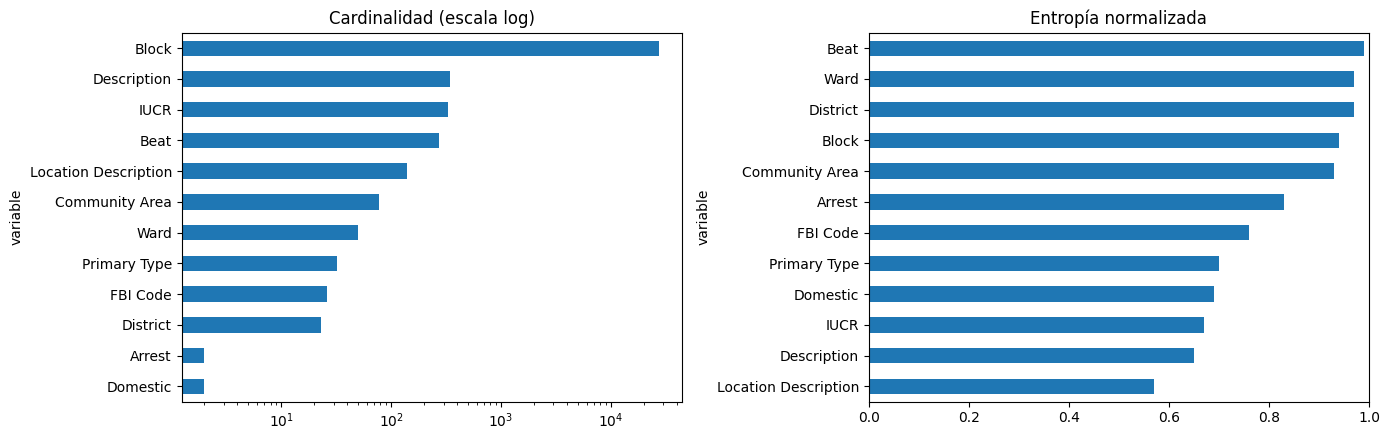

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(14, 4.5))
tabla_cat["cardinalidad"].sort_values().plot(kind="barh", logx=True, ax=ax[0])
ax[0].set_title("Cardinalidad (escala log)")
tabla_cat["entropía_norm"].sort_values().plot(kind="barh", ax=ax[1])
ax[1].set_title("Entropía normalizada")
ax[1].set_xlim(0, 1)
plt.tight_layout()
plt.show()

Text(0.5, 1.0, 'Heatmap egistros por día de la semana y hora')

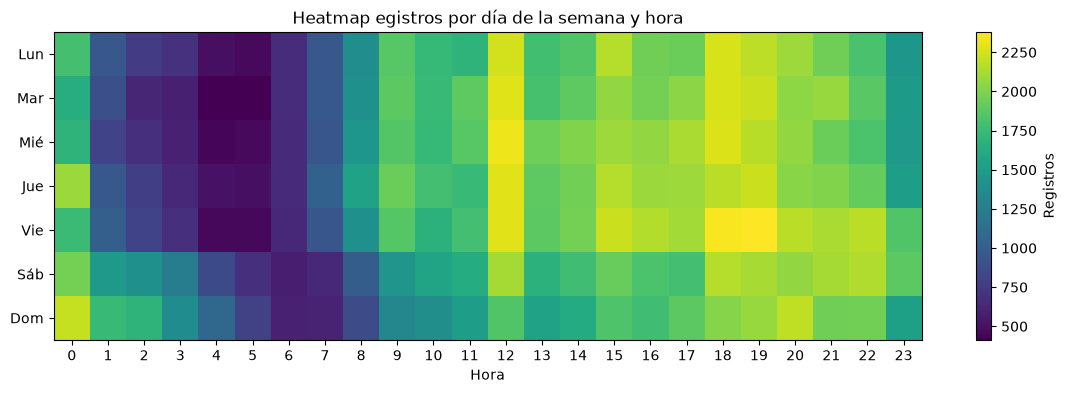

In [8]:
#Heatmap día de la semana vs hora
pivot = df.pivot_table(index="dia_semana", columns="hora", values="ID", aggfunc="count")
plt.figure(figsize=(14, 4))
plt.imshow(pivot, aspect="auto", cmap="viridis")
plt.colorbar(label="Registros")
plt.yticks(range(7), ["Lun", "Mar", "Mié", "Jue", "Vie", "Sáb", "Dom"])
plt.xticks(range(24))
plt.xlabel("Hora")
plt.title("Heatmap egistros por día de la semana y hora")


In [9]:
################################
# VALORES FALTANTES Y OUTLIERS #
################################

#VALORES FALTANTES
nulos = df.isna().sum()
nulos = nulos[nulos > 0].to_frame("n_nulos")
nulos["%"] = (nulos["n_nulos"] / fils_n * 100).round(3)
print(nulos)

# Como se noto anteriormente, los valores de locación (coordenadas, longitud, latitud)
# faltan en las mismas filas - o sea, estas filas simplement no tienen datos geográficos
# concretos
cols_geo = ["X Coordinate", "Y Coordinate", "Latitude", "Longitude", "Location"]
print("\n¿Coordenadas faltan para las mismas filas?:",
      (df[cols_geo].isna().sum(axis=1).isin([0, len(cols_geo)])).all())


                      n_nulos      %
Location Description      620  0.234
Ward                        2  0.001
Community Area             14  0.005
X Coordinate             7001  2.643
Y Coordinate             7001  2.643
Latitude                 7001  2.643
Longitude                7001  2.643
Location                 7001  2.643

¿Coordenadas faltan para las mismas filas?: True



Coordenadas faltantes por tipo (Total = 2.6% de los datos)
                             mean   size
Primary Type                            
CRIMINAL SEXUAL ASSAULT     0.419    148
OFFENSE INVOLVING CHILDREN  0.176   2527
SEX OFFENSE                 0.173   1054
DECEPTIVE PRACTICE          0.146  16502
OBSCENITY                   0.143     49
CRIM SEXUAL ASSAULT         0.101   1319
NARCOTICS                   0.097  23939
INTIMIDATION                0.057    123
STALKING                    0.052    155
OTHER OFFENSE               0.016  17566
THEFT                       0.011  57355
WEAPONS VIOLATION           0.009   3364
MOTOR VEHICLE THEFT         0.006  10068
BURGLARY                    0.006  13184
KIDNAPPING                  0.005    190

Variable: Primary Type
  Chi-Cuadrado: 21819.4438
  p-value: 0.0000e+00
  Asociación significante

Variable: Arrest
  Chi-Cuadrado: 361.4968
  p-value: 1.3294e-80
  Asociación significante

Variable: Domestic
  Chi-Cuadrado: 249.9179
  p-valu

Text(0.5, 0, '% faltante')

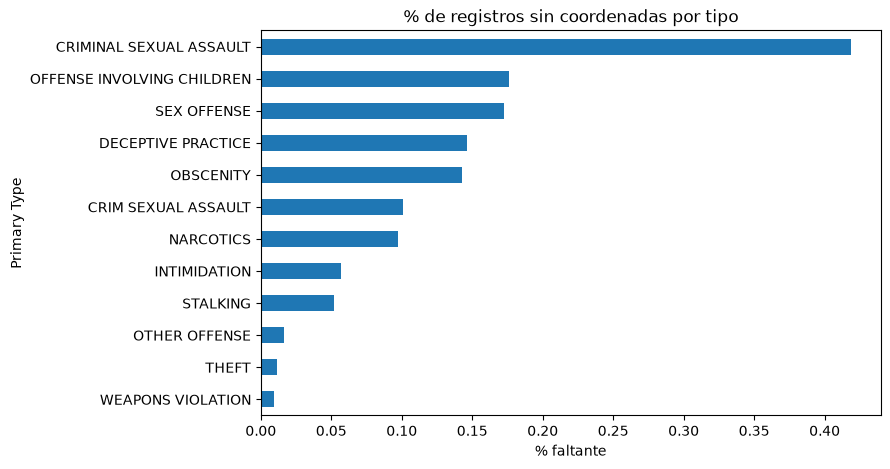

In [10]:
df["geo_falta"] = df["Latitude"].isna()
print("\nCoordenadas faltantes por tipo (Total = 2.6% de los datos)")
geo_por_tipo = (df.groupby("Primary Type")["geo_falta"]
                  .agg(["mean", "size"]).sort_values("mean", ascending=False))
print(geo_por_tipo.head(15).round(3))
for g in ["Primary Type", "Arrest", "Domestic"]:
    contingency_table = pd.crosstab(df[g], df["geo_falta"])
    chi2, p, dof, expected = chi2_contingency(contingency_table)
    print(f"\nVariable: {g}")
    print(f"  Chi-Cuadrado: {chi2:.4f}")
    print(f"  p-value: {p:.4e}")
    if p < 0.05:
        print("  Asociación significante")
    else:
        print("  Asociación insignificante.")

loc_descriptions = df.loc[df["geo_falta"], "Location Description"].value_counts(normalize=True).head(5)
print("\nTop 5 ubicaciones con coordenadas faltantes:")
print((loc_descriptions * 100).round(1).astype(str) + '%')

# Figura de faltantes
plt.figure(figsize=(8, 5))
(geo_por_tipo["mean"].head(12)
 .sort_values().plot(kind="barh"))
plt.title("% de registros sin coordenadas por tipo")
plt.xlabel("% faltante")
#50%+ en departamentos y residencias

# Los valores faltantes de localización no son MCAR ya que dependen fuertemente del tipo de delito
# Los crímenes sexuales y delitos contra menores parecen ser los más afectados
# Esto puede deberse a un anonimato con propósito ya que se intenta ocultar la identidad de las víctimas
# y la mayoría de los crímenes sexuales (especialmente contra menores) suelen ocurrir en el hogar
# Se puede quizás considerar entonces MNAR ya que la falta de locación depende del lugar del hecho en sí

# DECEPTIVE PRACTIVE (se refiere a fraude) también carece de locación porque es más dificil identificar dónde
# ocurrió el crimen (ya que suelen ser crímenes online/telefónicos)
# Se puede considerar MAR ya que la falta de locación está relacionada a la metodología del tipo de crimen

# Otra cosa a notar - CRIMINAL SEXUAL ASSAULT y CRIM SEXUAL ASSAULT figuran como dos categorías distintas
# de delito pero referencian un mismo crimen. Esto se puede tener en cuenta más adelante al limpiar y re-organizar los datos


In [11]:
df["locdesc_falta"] = df["Location Description"].isna()

df["anio_update"] = df["Updated On"].dt.year
print("\n% sin coordenadas según año de última actualización:")
print((df.groupby("anio_update")["geo_falta"].mean() * 100).round(1))

print("\nLocation Description (620 nulos):")
print(df.loc[df["locdesc_falta"], "Primary Type"].value_counts())
print(df.loc[df["locdesc_falta"], "Description"].value_counts().head(5))
#Notamos nuevamente que DECEPTIVE PRACTICE (fraude) no cuenta con datos de locación y en específico no cuenta
# La descripción nos deja más en claro el por qué: en la mayoría de los casos son crímenes de robo
# de identidad que no ocurren en un lugar físico (ejemplo: entrar en la cuenta bancaria de alguien online)
# Esto hace más fuerte la hipótesis de que es un dato faltante MAR
print("   -> 99% son DECEPTIVE PRACTICE (casi todos robo de identidad financiera):")
print("      el hecho no ocurre en un lugar físico. Faltante MAR /")
print("      estructural (no aplica un 'lugar'). Imputable como 'NO APLICA/ONLINE'.")

#Ward y Community Area
print("\nNulos en Ward y Community Area:")
print(df.loc[df["Ward"].isna() | df["Community Area"].isna(),
             ["Block", "Beat", "District", "Ward", "Community Area", "Latitude"]])
# Los null en Ward y Community Area se concentran en un mismo distrito (Jefferson Park)
# Sin embargo, cuentan con datos de coordenadas lo cuál los hace recuperables
# Aunque parece una haber una relación con el distrito, es posible que sean faltantes MCAR
# y que simplemente se olvidó de asignarles datos geográficos puntuales


% sin coordenadas según año de última actualización:
anio_update
2015     1.4
2016    73.1
2017    97.7
2018     1.3
2019    70.5
2020    64.1
2021     4.0
2022    15.6
2023    50.6
2024    55.6
2025     3.3
2026    55.1
Name: geo_falta, dtype: float64

Location Description (620 nulos):
Primary Type
DECEPTIVE PRACTICE    616
THEFT                   1
BATTERY                 1
ROBBERY                 1
ASSAULT                 1
Name: count, dtype: int64
Description
FINANCIAL IDENTITY THEFT OVER $ 300        544
FINANCIAL IDENTITY THEFT $300 AND UNDER     63
CREDIT CARD FRAUD                            4
ILLEGAL USE CASH CARD                        3
AGGRAVATED - HANDGUN                         2
Name: count, dtype: int64
   -> 99% son DECEPTIVE PRACTICE (casi todos robo de identidad financiera):
      el hecho no ocurre en un lugar físico. Faltante MAR /
      estructural (no aplica un 'lugar'). Imputable como 'NO APLICA/ONLINE'.

Nulos en Ward y Community Area:
                       

In [12]:
#Datos duplicados e inconsistentes

print(f"Filas duplicadas completas: {df.duplicated().sum()}")
print(f"IDs duplicados: {df['ID'].duplicated().sum()}")
dup_case = df[df["Case Number"].duplicated(keep=False)]
print(f"Case Number repetidos: {df['Case Number'].duplicated().sum()} "
      f"(filas involucradas: {len(dup_case)})\n")

print(dup_case["Primary Type"].value_counts())
#Todos los casos de Case Number repetido se deben a casos de homicidio dónde cada fila
# representa a una víctima. Son repetidos por diseño: un mismo caso con varias víctimas

print("\nMisma categoría de crimen con dos nombres (IUCR idénticos):")
iucr_multi = df.groupby("IUCR")["Primary Type"].nunique()
print(df[df["IUCR"].isin(iucr_multi[iucr_multi > 1].index)]
      .groupby(["Primary Type"])["anio_update"].agg(["size", "min", "max"]))
# Como ya vimos más arriba, CRIMINAL SEXUAL ASSAULT y CRIM SEXUAL ASSAULT representan un mismo crimen
# Ahora podemos notar que la categoría fue renombrada en 2020-2021 y por eso hay una inconsistencia
# Lo ideal sería unificarlos o utilizar solo el IUCR al tratar con el tipo de crimen de ahora en adelante

print(f"\nLocation Description: {df['Location Description'].nunique()} categorías,")
print(sorted(df['Location Description'].dropna().unique()))
# Podemos notar algunos casos de descripción de locación repetida por pequeñas inconsistencias
#EJ: 'VACANT LOT / LAND' y 'VACANT LOT/LAND' o 'SCHOOL, PRIVATE, GROUNDS' y 'SCHOOL - PRIVATE GROUNDS'
# Lo ideal sería normalizar las descripciones para poder agruparlas correctamente


incons = df[df["Beat"] // 100 != df["District"]]
print(f"\nBeat inconsistente con District: {len(incons)} registros")
print(incons.groupby(["Beat", "District"]).size().sort_values(ascending=False).head())
# Mismo valor de Beat perteneciendo a distintos distritos - corregible aunque se debería analizar
# si se debe a que esos beats fueron re-organizados a otro distrito o si fue un error

valid_districts = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 14, 15, 16, 17, 18, 19, 20, 22, 24, 25]
print(f"\nDistritos no policiales: {(~df['District'].isin(valid_districts)).sum()} registros.")
# Chicago cuenta con 22 distritos policiales. Es posible que estos registros con distrito policial
# no existente se deban a que se utilizó otra definición de distrito

print(f"\n'NON-CRIMINAL' como tipo: {(df['Primary Type'] == 'NON-CRIMINAL').sum()}")
# Se podría considerar si excluir registros que no estén vinculados a un delito

Filas duplicadas completas: 0
IDs duplicados: 0
Case Number repetidos: 27 (filas involucradas: 50)

Primary Type
HOMICIDE    50
Name: count, dtype: int64

Misma categoría de crimen con dos nombres (IUCR idénticos):
                         size   min   max
Primary Type                             
CRIM SEXUAL ASSAULT      1284  2015  2021
CRIMINAL SEXUAL ASSAULT   148  2020  2026

Location Description: 140 categorías,
['ABANDONED BUILDING', 'AIRCRAFT', 'AIRPORT BUILDING NON-TERMINAL - NON-SECURE AREA', 'AIRPORT BUILDING NON-TERMINAL - SECURE AREA', 'AIRPORT EXTERIOR - NON-SECURE AREA', 'AIRPORT EXTERIOR - SECURE AREA', 'AIRPORT PARKING LOT', 'AIRPORT TERMINAL LOWER LEVEL - NON-SECURE AREA', 'AIRPORT TERMINAL LOWER LEVEL - SECURE AREA', 'AIRPORT TERMINAL MEZZANINE - NON-SECURE AREA', 'AIRPORT TERMINAL UPPER LEVEL - NON-SECURE AREA', 'AIRPORT TERMINAL UPPER LEVEL - SECURE AREA', 'AIRPORT TRANSPORTATION SYSTEM (ATS)', 'AIRPORT VENDING ESTABLISHMENT', 'AIRPORT/AIRCRAFT', 'ALLEY', 'ANIMAL H

Coordenadas fuera de Chicago: 0

Registros a las 00h: 13,136 vs promedio de otras horas 10,947

Exactamente 00:00: 2,923

Registros el día 1 del mes: 11,083 vs promedio 8,461 en otros días

Registros con minuto == 00: 34.5%, si fuera uniforme: 1.7%

Tipos más frecuentes a las 00:00 en el primer día del mes:
604
Primary Type
DECEPTIVE PRACTICE            200
OFFENSE INVOLVING CHILDREN    137
SEX OFFENSE                    60
CRIM SEXUAL ASSAULT            53
THEFT                          41
Name: count, dtype: int64

Delitos por día: límite superior IQR = 938; outliers = 6
Date
2015-01-01    1300
2015-08-01    1052
2015-11-01     998
2015-09-01     961
2015-06-01     959
2015-05-01     957
dtype: int64

Delitos por Community Area: límite superior IQR = 10,561; outliers = 1
Community Area
25.0    17436
dtype: int64


/tmp/ipykernel_517182/398344529.py:65: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(por_area.values, vert=False)


Text(0.5, 1.0, 'Distribución de delitos por Community Area')

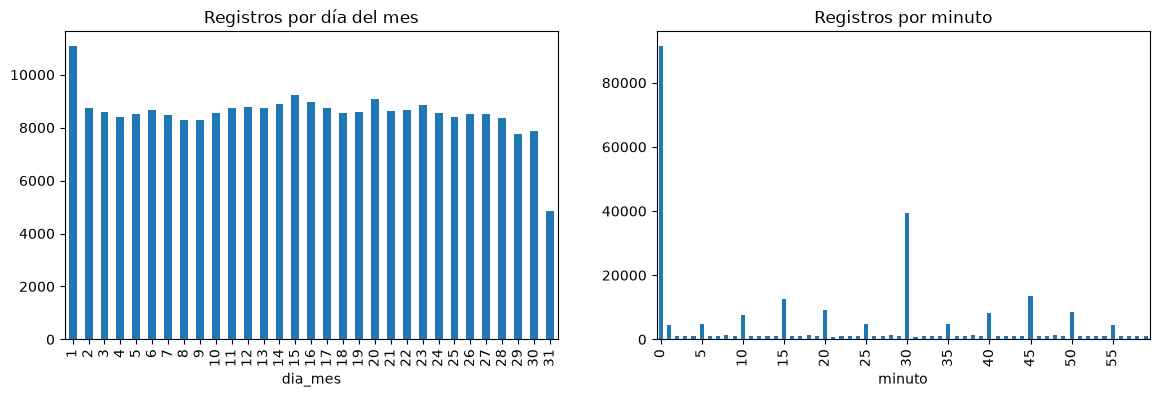

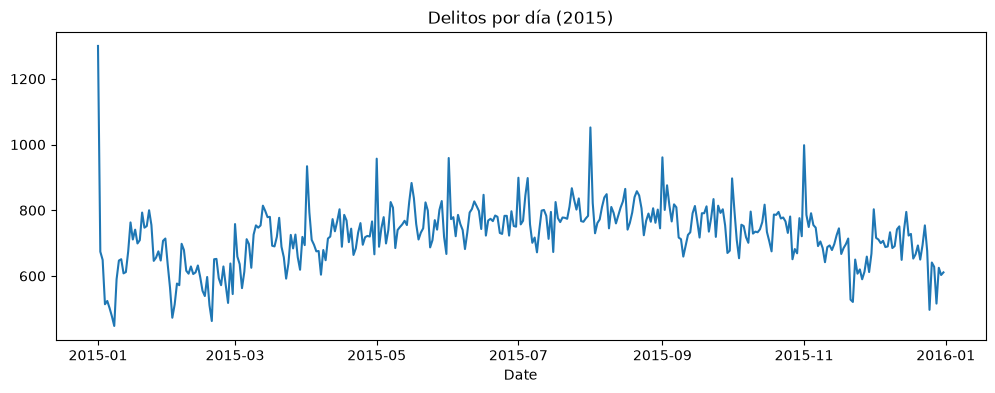

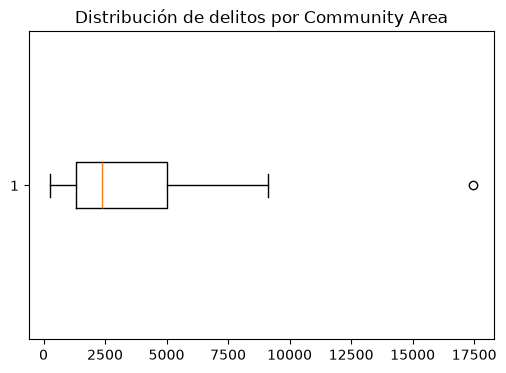

In [13]:
############
# OUTLIERS #
############

#Espaciales
fuera_chicago = df[(df["Latitude"] < 41.6) | (df["Latitude"] > 42.1) |
           (df["Longitude"] < -87.95) | (df["Longitude"] > -87.5)]
print(f"Coordenadas fuera de Chicago: {len(fuera_chicago)}")
# Haciendo un rectángulo que más o menos describe el área de Chicago no se encuentra ninguna
# coordenada que parezca estar por fuera

#Temporales
media_hora = df["hora"].value_counts().drop(0).mean()
media_dia = df["dia_mes"].value_counts().drop(1).mean()
exacta_00 = ((df["hora"] == 0) & (df["minuto"] == 0))

print(f"\nRegistros a las 00h: {(df['hora'] == 0).sum():,} vs promedio de otras "
      f"horas {media_hora:,.0f}")
print(f"\nExactamente 00:00: {exacta_00.sum():,}")
print(f"\nRegistros el día 1 del mes: {(df['dia_mes'] == 1).sum():,} vs promedio "
      f"{media_dia:,.0f} en otros días")
print(f"\nRegistros con minuto == 00: {(df['minuto'] == 0).mean():.1%}, si fuera uniforme: {(1/60):.1%}")

print("\nTipos más frecuentes a las 00:00 en el primer día del mes:")
primer_exacta_00 = exacta_00 & (df["dia_mes"] == 1)
print(primer_exacta_00.sum())
print(df.loc[primer_exacta_00, "Primary Type"].value_counts().head(5))

# Parece ser que cuáno la fecha/hora real se desconocen en casos dónde es difícil saber con exactitud
# (fraudes, abuso sexual o abusos de menores) se registra el crimen a la hora 00:00 en el primer día del mes
# Se puede ver como un valor "por defecto" para llenar la planilla en vez de un dato real

fig, ax = plt.subplots(1, 2, figsize=(14, 4))
df["dia_mes"].value_counts().sort_index().plot(kind="bar", ax=ax[0],
                                               title="Registros por día del mes")
df["minuto"].value_counts().sort_index().plot(kind="bar", ax=ax[1],
                                              title="Registros por minuto")
ax[1].set_xticks(range(0, 60, 5))

#Outliers con IQR
def outliers_iqr(serie, nombre):
    q1, q3 = serie.quantile([0.25, 0.75])
    lim = q3 + 1.5 * (q3 - q1)
    out = serie[serie > lim].sort_values(ascending=False)
    print(f"\n{nombre}: límite superior IQR = {lim:,.0f}; outliers = {len(out)}")
    print(out.head(8))
    return out

por_dia = df.groupby(df["Date"].dt.date).size()
outliers_iqr(por_dia, "Delitos por día")
# Con el IQR, volvemos a notar una tendencia a que los crímenes ocurran el primero del mes
# Esto hace nuestra hipótesis de "día default" más fuerte.
# Notese también que el MAYOR outlier es el primer día del primer mes del año. Es posible que enero también
# sea un mes default para agrupar crímenes o que los crímenes que ocurren en el periodo de fiestas se registren un mismo día

outliers_iqr(por_area, "Delitos por Community Area")
# 25 representa a Austin - a pesar de ser un outlier, en el 2015 era el área más poblada de Chicago al igual que una de las más
# pobres y con mayor desempleo, lo cuál puede explicar la densidad de crímenes superior a otras Community Areas

plt.figure(figsize=(12, 4))
por_dia.plot()
plt.title("Delitos por día (2015)")

plt.figure(figsize=(6, 4))
plt.boxplot(por_area.values, vert=False)
plt.title("Distribución de delitos por Community Area")


In [14]:
############################
# RESUMEN CALIDAD DE DATOS #
############################

resumen_calidad = pd.DataFrame([
    ["Coordenadas (X, Y, Lat, Lon, Location)", "7001 (2,6%)",
     "MAR o MNAR dependiendo el caso",
     "Redactado por privacidad en casos de delitos sexuales/menores (hogar locación principal) o por locación física ambigua (fraude)"
    ],
    ["Location Description", "620 (0,2%)", "MAR",
     "99% son casos de fraude sin lugar físico"],
    ["Community Area", "14", "Aparente MCAR", "Falla puntual de geocodificación específicamente en los Beat 1614 y 1654"],
    ["Ward", "2", "Aparente MCAR", "Falla puntual de geocodificación"],
    ["Hora 00:00 y día 1 del mes", "apróx 2900", "MNAR o MAR: Faltante encubierto, a veces por tipo de caso",
     "Valor por defecto cuando la fecha real es desconocida"],
    ["Case Number repetido", "27", "Por diseño", "Homicidios se representan con una fila por víctima"],
    ["CRIM vs CRIMINAL SEXUAL ASSAULT", "1467", "Error de consistencia",
     "Categoría renombrada entre 2020/2021"],
    ["Location Description", "140 categorías", "Error de consistencia",
     "Misma categoría con distinta puntuación"],
    ["District inválido", "9", "Error", "Categorización inconsistente (distritos no policiales utilizados)"],
], columns=["Variable afectada", "Valores afectados", "Tipo", "Razones"])
print(resumen_calidad.to_string(index=False))

                     Variable afectada Valores afectados                                                      Tipo                                                                                                                         Razones
Coordenadas (X, Y, Lat, Lon, Location)       7001 (2,6%)                            MAR o MNAR dependiendo el caso Redactado por privacidad en casos de delitos sexuales/menores (hogar locación principal) o por locación física ambigua (fraude)
                  Location Description        620 (0,2%)                                                       MAR                                                                                        99% son casos de fraude sin lugar físico
                        Community Area                14                                             Aparente MCAR                                                        Falla puntual de geocodificación específicamente en los Beat 1614 y 1654
                            

In [15]:
# Para darle facha a los gráficos

NAVY = "#13294B"
RED  = "#C8102E"
TEAL = "#10656B"
GRAY = "#5A5F6A"

sns.set_theme(style="whitegrid")

plt.rcParams.update({
    "figure.facecolor":  "white",
    "axes.facecolor":    "white",
    "axes.edgecolor":    "#D8DAE0",
    "axes.labelcolor":   GRAY,
    "axes.titlesize":    13,
    "axes.titleweight":  "bold",
    "axes.titlecolor":   GRAY,
    "axes.titlepad":     14,
    "axes.grid":         True,
    "grid.color":        "#E8E9ED",
    "grid.linewidth":    0.6,
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "xtick.color":       GRAY,
    "ytick.color":       GRAY,
    "font.size":         11,
    "figure.dpi":        110,
})